# 02 · Agente baseline y cascada de disponibilidad

**Objetivo.** Sobre los 12 informes 10-K locales (NVDA, MSFT, AAPL, GOOGL, META y AMZN; FY2024–FY2025), un agente convierte una pregunta en consultas a herramientas y devuelve una respuesta estructurada.

Este cuaderno tiene dos recorridos distintos. El **baseline oficial** usa un único modelo fijo para poder medirlo después. La **cascada** es una variante de disponibilidad: si el modelo principal falla por red, cuota o proveedor, prueba el siguiente. No pide tres respuestas ni mezcla opiniones.

Este notebook requiere OpenRouter para recorrer el agente de principio a fin. La clave se lee sólo desde el entorno o `.env`; nunca se escribe ni se muestra en una celda.


In [1]:
import os, sys, pathlib, time
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p/'pyproject.toml').exists())
sys.path.insert(0, str(RAIZ/'src'))
import matplotlib.pyplot as plt, pandas as pd
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from agente10k import agente, config
from agente10k.herramientas import TOOLS
plt.style.use('seaborn-v0_8-whitegrid')

# Seguridad: no pegues la clave aquí. config.cargar_clave() la lee de OPENROUTER_API_KEY o .env.
# Este recorrido mide modelos y cascada reales; necesita OPENROUTER_API_KEY.
EJECUTAR_API = os.environ.get('AGENTE10K_EJECUTAR_API', '1') == '1'
# Ejecución acotada: una decisión de herramienta y una respuesta final por pregunta.
os.environ['AGENTE10K_MODO_ACOTADO'] = '1'
assert config.cargar_clave(), 'Falta OPENROUTER_API_KEY en el entorno o en .env.'
# Preflight: prueba red y cliente antes de iniciar la batería completa.
PRECHECK_API = config.crear_modelo('openrouter:nex-agi/nex-n2.5-pro:free').invoke('Responde exactamente: OK').content
assert str(PRECHECK_API).strip().upper() == 'OK', f'OpenRouter no superó el preflight: {PRECHECK_API!r}'
print(f'Baseline fijo: {config.MODELO_ID} | temperatura={config.TEMPERATURA} | API activa: {EJECUTAR_API}')


Baseline fijo: openrouter:google/gemini-3.8-flash | temperatura=0 | API activa: True


## 1. Qué problema resuelve cada versión

**Entrada.** Una pregunta financiera sobre el corpus local. **Proceso.** El modelo decide qué herramienta consultar, revisa la observación y completa el contrato. **Salida.** Una respuesta breve con evidencia y métricas.

El baseline responde con un modelo fijo. La cascada sólo cambia de modelo tras un fallo técnico; por tanto, una respuesta válida del principal termina el recorrido inmediatamente.

**Nota de ejecución.** El baseline oficial de la librería conserva LangGraph y `ToolStrategy`. Para probar proveedores gratuitos de forma reproducible, este notebook activa un arnés acotado: el LLM elige una herramienta, se ejecuta esa llamada y el mismo LLM redacta la respuesta final; el contrato Pydantic y la traza siguen verificándose. Se etiqueta como prueba de compatibilidad, no como sustituto de la evaluación final del baseline oficial.


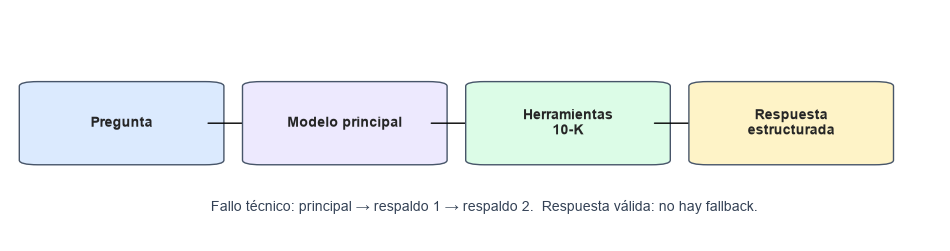

In [2]:
fig, ax = plt.subplots(figsize=(12, 3)); ax.axis('off')
pasos = [('Pregunta', '#dbeafe'), ('Modelo principal', '#ede9fe'), ('Herramientas\n10-K', '#dcfce7'), ('Respuesta\nestructurada', '#fef3c7')]
for i, (etiqueta, color) in enumerate(pasos):
    x = .03 + i*.24
    ax.add_patch(FancyBboxPatch((x,.35), .18,.32, boxstyle='round,pad=.02', facecolor=color, edgecolor='#475569'))
    ax.text(x+.09,.51,etiqueta,ha='center',va='center',weight='bold')
    if i < 3: ax.add_patch(FancyArrowPatch((x+.18,.51),(x+.235,.51),arrowstyle='->',mutation_scale=15))
ax.text(.51,.13,'Fallo técnico: principal → respaldo 1 → respaldo 2.  Respuesta válida: no hay fallback.',ha='center',color='#334155')
plt.show()


## 2. Contrato: una respuesta que se puede comprobar

La respuesta no es texto libre. Los ocho campos obligatorios permiten comprobar cifra, unidad, empresa, ejercicio y evidencia. Una cifra sólo procede de XBRL; si falta realmente en el corpus se devuelve `cifra=None` y `fuente="ninguna"`.

La visual enseña los campos que debe completar cualquier modelo de la cascada. Así cambiar de proveedor no cambia el formato que consume el resto del proyecto.


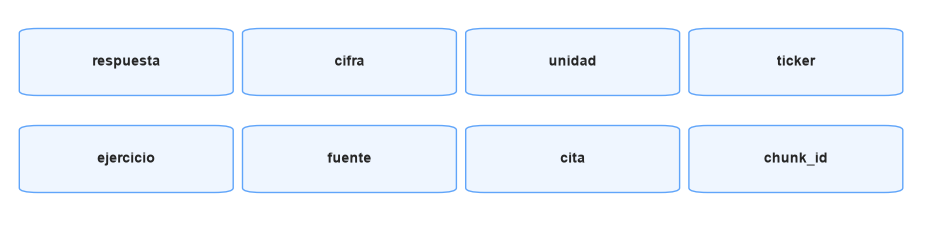

In [3]:
campos = list(agente.RespuestaFinanciera.model_fields)[:8]
fig, ax = plt.subplots(figsize=(12, 3)); ax.axis('off')
for i, campo in enumerate(campos):
    fila, col = divmod(i, 4); x, y = .03+col*.24, .65-fila*.42
    ax.add_patch(FancyBboxPatch((x,y),.19,.25,boxstyle='round,pad=.02',facecolor='#eff6ff',edgecolor='#60a5fa'))
    ax.text(x+.095,y+.125,campo,ha='center',va='center',fontsize=10,weight='bold')
plt.show()


## 3. Herramientas antes que intuiciones

Esta tabla es la regla operativa que recibe el agente. **Cifra exacta** usa XBRL; **explicación o riesgo** busca texto; una sección completa sólo se lee cuando la búsqueda no localiza el pasaje. Preguntar por cobertura es el único caso de `list_available`.

El coste relativo no es precio en dólares: indica cuánta información devuelve cada herramienta y ayuda a evitar pedir una sección entera innecesariamente.


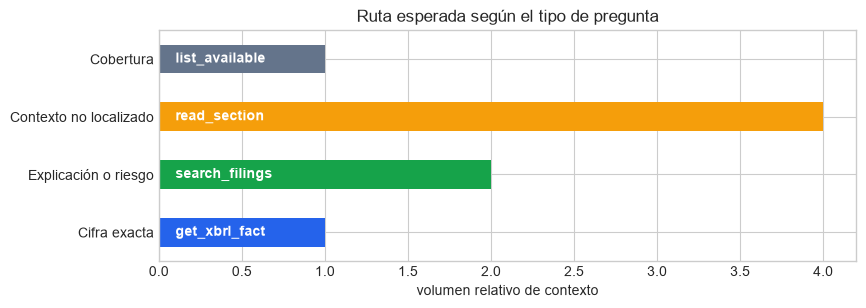

In [4]:
rutas = pd.DataFrame([
 ['Cifra exacta', 'get_xbrl_fact', 1], ['Explicación o riesgo', 'search_filings', 2],
 ['Contexto no localizado', 'read_section', 4], ['Cobertura', 'list_available', 1]],
 columns=['necesidad','herramienta','coste relativo'])
ax=rutas.set_index('necesidad')['coste relativo'].plot.barh(color=['#2563eb','#16a34a','#f59e0b','#64748b'], figsize=(9,3))
ax.set_xlabel('volumen relativo de contexto'); ax.set_ylabel(''); ax.set_title('Ruta esperada según el tipo de pregunta')
for i, herramienta in enumerate(rutas['herramienta']): ax.text(.1,i,herramienta,va='center',color='white',weight='bold')
plt.show()


## 4. Baseline oficial: un modelo, una referencia estable

`construir_agente("baseline")` une el modelo fijado en configuración, las cuatro herramientas, memoria por hilo y `ToolStrategy(RespuestaFinanciera)`. Se mantiene sin cascada para que las evaluaciones futuras comparen exactamente el mismo punto de partida.

La función `ejecutar()` crea un hilo nuevo, captura errores y devuelve además de la respuesta: llamadas de herramientas, tokens comunicados por el proveedor, USD si el proveedor lo informa y latencia.


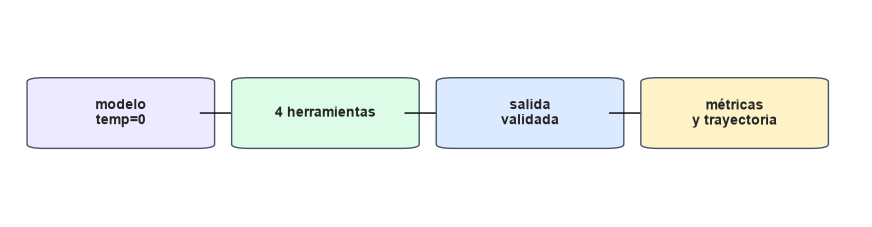

Herramientas registradas: list_available, get_xbrl_fact, search_filings, read_section


In [5]:
fig, ax = plt.subplots(figsize=(11,2.7)); ax.axis('off')
componentes=[('modelo\ntemp=0','#ede9fe'),('4 herramientas','#dcfce7'),('salida\nvalidada','#dbeafe'),('métricas\ny trayectoria','#fef3c7')]
for i,(texto,color) in enumerate(componentes):
    x=.04+i*.24; ax.add_patch(FancyBboxPatch((x,.35),.18,.3,boxstyle='round,pad=.02',facecolor=color,edgecolor='#475569'))
    ax.text(x+.09,.5,texto,ha='center',va='center',weight='bold')
    if i<3: ax.add_patch(FancyArrowPatch((x+.18,.5),(x+.235,.5),arrowstyle='->',mutation_scale=14))
plt.show()
print('Herramientas registradas:', ', '.join(h.name for h in TOOLS))


## 5. Prueba de humo con OpenRouter: una sola pregunta

Esta es la primera llamada real. Por defecto se ejecuta si existe `OPENROUTER_API_KEY` en el entorno o en `.env`, que está ignorado por Git; usa `AGENTE10K_EJECUTAR_API=0` para desactivarla. No muestra ni guarda la clave.

Cómo leer la salida: `respuesta` es el resultado para la persona; `tool_calls` permite comprobar la ruta; `modelo`, `latencia_s`, `uso_mensajes` y `usd_openrouter` documentan el coste operativo. Si no hay clave, la celda explica cómo activarla y no hace red.


In [6]:
MODELO_HUMO = os.environ.get('AGENTE10K_MODELO_HUMO', 'openrouter:nex-agi/nex-n2.5-pro:free')
pregunta_humo = '¿Cuál fue el revenue total de NVIDIA (NVDA) en FY2024? Da la cifra exacta, unidad y concepto XBRL.'
if EJECUTAR_API and config.cargar_clave():
    humo = agente.ejecutar(pregunta_humo, sistema='cascada', modelo=MODELO_HUMO,
                             fallbacks=['openrouter:inclusionai/ling-3.0-flash-fin:free',
                                        'openrouter:nex-agi/nex-n2.5-pro:free'])
    display(pd.Series({k: humo[k] for k in ['modelo','latencia_s','usd_openrouter','n_llamadas','error']}))
    display(humo['respuesta'])
    display(pd.DataFrame(humo['tool_calls']))
else:
    print('Sin llamada: deja AGENTE10K_EJECUTAR_API sin activar para el modo local. Para probar: añade OPENROUTER_API_KEY a .env e inicia con AGENTE10K_EJECUTAR_API=1.')


modelo            openrouter:nex-agi/nex-n2.5-pro:free
latencia_s                                   13.867236
usd_openrouter                                    None
n_llamadas                                           1
error                                             None
dtype: object

RespuestaFinanciera(respuesta='- **Cifra:** 60,922,000,000 USD\n- **Concepto XBRL:** `Revenues`\n- **Ejercicio fiscal:** FY2024\n- **Cierre fiscal:** 28 de enero de 2024', cifra=60922000000.0, unidad='USD', ticker='NVDA', ejercicio=2024, fuente='xbrl', cita=None, chunk_id=None, concept_xbrl='Revenues', ejercicio_base=None, cifra_base=None)

,name,args,id
0,get_xbrl_fact,"{'ticker': 'NVDA', 'fiscal_year': 2024, 'conce...",call_8acaf39f2d064215a117a5ca


## 6. Banco de candidatos: medir antes de elegir

La cascada no se decide por fama. Esta lista usa identificadores concretos, gratuitos en el momento de preparar el cuaderno, y dos preguntas representativas para todos; el golden set ampliará la evaluación. Se mide contrato válido, ruta esperada, abstención, latencia, tokens, USD y error. La oferta gratuita cambia: antes de gastar tiempo o cuota, confirma en el catálogo de OpenRouter que siguen disponibles y admiten herramientas.

El banco mide cada candidato **aislado** y reintenta sólo el mismo candidato tras un corte transitorio. Así `modelo_real` debe coincidir con el solicitado: no confundimos calidad del candidato con un respaldo. La cascada se prueba después, sólo con los tres elegidos. Se conservan intentos y errores; si no hay clave, no se simulan resultados.


In [7]:
# IDs concretos: se prueban individualmente, no mediante el router cambiante openrouter/free.
# Mantén sólo los que sigan siendo gratuitos y compatibles con herramientas en el catálogo.
CANDIDATOS = [
    'openrouter:nex-agi/nex-n2.5-pro:free',
    'openrouter:nvidia/nemotron-3-ultra-550b-a55b:free',
    'openrouter:google/gemma-4-26b-a4b-it:free',
    'openrouter:inclusionai/ling-3.0-flash-fin:free',
    'openrouter:nvidia/nemotron-3-super-120b-a12b:free',
]
CANDIDATOS = CANDIDATOS[:10]
CASOS_BANCO = pd.DataFrame([
 ['¿Cuál fue el revenue total de NVIDIA (NVDA) en FY2024? Da la cifra exacta, unidad y concepto XBRL.', 'get_xbrl_fact', 'xbrl'],
 ['Según el 10-K de Microsoft (MSFT) FY2025, ¿qué riesgo concreto relacionado con IA describe la empresa? Cita literalmente el fragmento.', 'search_filings', 'texto'],
 ['¿Cuál fue el gross profit de Amazon (AMZN) en FY2025? Si el concepto no está reportado en el corpus, abstente sin estimarlo.', 'get_xbrl_fact', 'ninguna'],
 ['¿Hay datos de Tesla (TSLA) para FY2023 en este corpus? Si no, indica claramente que está fuera de cobertura.', 'list_available', 'ninguna'],
], columns=['pregunta','ruta esperada','fuente esperada'])
# Ejecución rápida y reproducible: dos controles complementarios (dato y texto).
# El golden set posterior ampliará esta batería sin convertir este notebook en una espera larga.
CASOS_BANCO = CASOS_BANCO.iloc[:2].copy()
display(CASOS_BANCO)
print(f'{len(CANDIDATOS)} candidato(s) configurado(s); máximo permitido: 10.')


,pregunta,ruta esperada,fuente esperada
0,¿Cuál fue el revenue total de NVIDIA (NVDA) en...,get_xbrl_fact,xbrl
1,"Según el 10-K de Microsoft (MSFT) FY2025, ¿qué...",search_filings,texto


5 candidato(s) configurado(s); máximo permitido: 10.


## 7. Selección: fiabilidad antes que inteligencia aislada

Tras ejecutar el banco con API, cada fila será una interacción modelo–pregunta. Un modelo que no cumple el esquema, no consulta la ruta requerida o no se abstiene cuando el corpus no tiene el dato no debe encabezar la cascada aunque sea rápido.

La puntuación propuesta da prioridad a completar respuestas válidas y a respetar el contrato. Además mide si el **modelo solicitado** fue el que atendió: un caso resuelto por respaldo mantiene la evidencia de calidad, pero no se atribuye falsamente como disponibilidad del principal. Coste y latencia sólo desempatan. Los seis gráficos muestran puntuación, latencia, USD, ruta, intentos y fallback por separado: no ocultes una métrica débil detrás de una media. La primera terna se ordena como principal, respaldo 1 y respaldo 2.


C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'[WinError 10061] No se puede establecer una conexión ya que el equipo de destino denegó expresamente dicha conexión' thrown while requesting HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/adapter_config.json


Retrying in 1s [Retry 1/5].


'[WinError 10061] No se puede establecer una conexión ya que el equipo de destino denegó expresamente dicha conexión' thrown while requesting HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/adapter_config.json


Retrying in 2s [Retry 2/5].


...

'[WinError 10061] No se puede establecer una conexión ya que el equipo de destino denegó expresamente dicha conexión' thrown while requesting HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/2_Normalize/config.json


Retrying in 8s [Retry 5/5].


'[WinError 10061] No se puede establecer una conexión ya que el equipo de destino denegó expresamente dicha conexión' thrown while requesting HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/2_Normalize/config.json


,esquema_valido,ruta_correcta,abstencion_correcta,fuente_correcta,sin_error,latencia_s,tokens,usd,hubo_fallback,principal_atendio,intentos,puntuacion
modelo,,,,,,,,,,,,
openrouter:inclusionai/ling-3.0-flash-fin:free,1.0,1.0,1.0,1.0,1.0,4.719,6554.0,0.0,0.0,1.0,1.0,1.0
openrouter:nvidia/nemotron-3-ultra-550b-a55b:free,1.0,1.0,1.0,1.0,1.0,15.967,6301.5,0.0,0.0,1.0,1.5,1.0
openrouter:nvidia/nemotron-3-super-120b-a12b:free,1.0,1.0,1.0,1.0,1.0,19.093,6461.5,0.0,0.0,1.0,1.0,1.0
openrouter:nex-agi/nex-n2.5-pro:free,1.0,1.0,1.0,1.0,1.0,181.512,5865.0,0.0,0.0,1.0,1.0,1.0
openrouter:google/gemma-4-26b-a4b-it:free,1.0,0.0,1.0,0.0,0.0,0.000,0.0,0.0,0.0,1.0,2.0,0.6


,modelo,pregunta,esquema_valido,ruta_correcta,abstencion_correcta,fuente_correcta,sin_error,latencia_s,tokens,usd,modelo_real,hubo_fallback,principal_atendio,intentos,errores_previos,ruta_observada,error
0,openrouter:nex-agi/nex-n2.5-pro:free,¿Cuál fue el revenue total de NVIDIA (NVDA) en...,True,True,True,True,True,8.708991,4390,0.0,nex-agi/nex-n2.5-pro:free,False,True,1,,get_xbrl_fact,None
1,openrouter:nex-agi/nex-n2.5-pro:free,"Según el 10-K de Microsoft (MSFT) FY2025, ¿qué...",True,True,True,True,True,354.315785,7340,0.0,nex-agi/nex-n2.5-pro:free,False,True,1,,search_filings,None
2,openrouter:nvidia/nemotron-3-ultra-550b-a55b:free,¿Cuál fue el revenue total de NVIDIA (NVDA) en...,True,True,True,True,True,5.580345,4687,0.0,nvidia/nemotron-3-ultra-550b-a55b:free,False,True,2,ResponseValidationError: Response validation f...,get_xbrl_fact,None
3,openrouter:nvidia/nemotron-3-ultra-550b-a55b:free,"Según el 10-K de Microsoft (MSFT) FY2025, ¿qué...",True,True,True,True,True,26.353045,7916,0.0,nvidia/nemotron-3-ultra-550b-a55b:free,False,True,1,,search_filings,None
4,openrouter:google/gemma-4-26b-a4b-it:free,¿Cuál fue el revenue total de NVIDIA (NVDA) en...,True,False,True,False,False,0.000000,0,0.0,openrouter:google/gemma-4-26b-a4b-it:free,False,True,2,TooManyRequestsResponseError: Provider returne...,sin herramienta,TooManyRequestsResponseError: Provider returne...
5,openrouter:google/gemma-4-26b-a4b-it:free,"Según el 10-K de Microsoft (MSFT) FY2025, ¿qué...",True,False,True,False,False,0.000000,0,0.0,openrouter:google/gemma-4-26b-a4b-it:free,False,True,2,TooManyRequestsResponseError: Provider returne...,sin herramienta,TooManyRequestsResponseError: Provider returne...
6,openrouter:inclusionai/ling-3.0-flash-fin:free,¿Cuál fue el revenue total de NVIDIA (NVDA) en...,True,True,True,True,True,3.171128,4805,0.0,inclusionai/ling-3.0-flash-fin:free,False,True,1,,get_xbrl_fact,None
7,openrouter:inclusionai/ling-3.0-flash-fin:free,"Según el 10-K de Microsoft (MSFT) FY2025, ¿qué...",True,True,True,True,True,6.267413,8303,0.0,inclusionai/ling-3.0-flash-fin:free,False,True,1,,search_filings → list_available,None
8,openrouter:nvidia/nemotron-3-super-120b-a12b:free,¿Cuál fue el revenue total de NVIDIA (NVDA) en...,True,True,True,True,True,19.277942,4726,0.0,nvidia/nemotron-3-super-120b-a12b:free,False,True,1,,get_xbrl_fact,None
9,openrouter:nvidia/nemotron-3-super-120b-a12b:free,"Según el 10-K de Microsoft (MSFT) FY2025, ¿qué...",True,True,True,True,True,18.907143,8197,0.0,nvidia/nemotron-3-super-120b-a12b:free,False,True,1,,search_filings,None


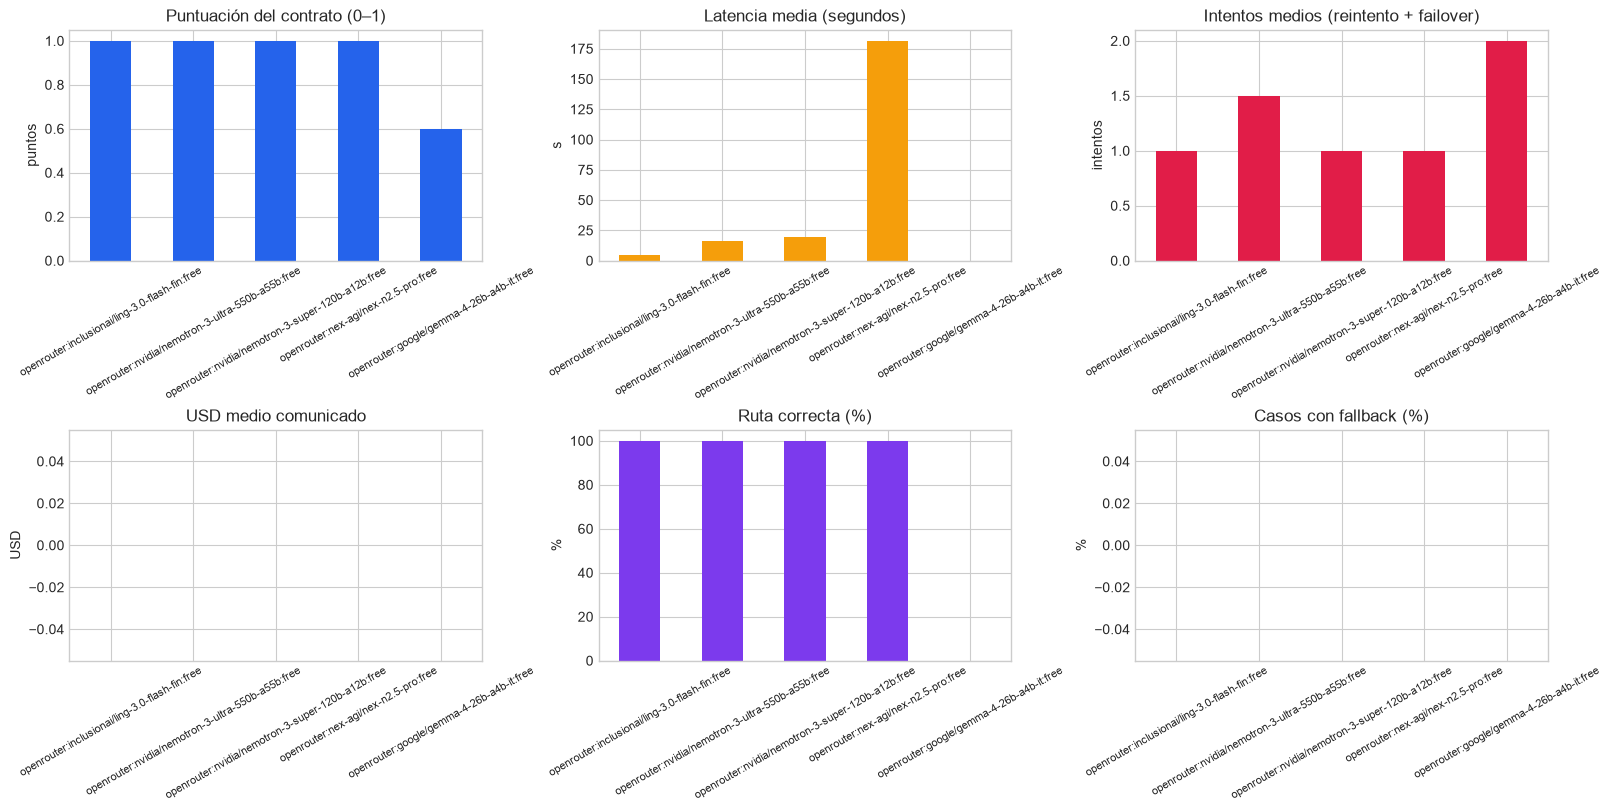

In [8]:
PESOS = {'esquema_valido': .30, 'ruta_correcta': .25, 'abstencion_correcta': .20, 'sin_error': .15, 'principal_atendio': .10}
MAX_INTENTOS = 2  # Reintento acotado: evita gastar la cuota indefinidamente.
ESPERA_REINTENTO_S = 2

def ejecutar_candidato_con_disponibilidad(pregunta, candidato):
    """Mide un candidato aislado y reintenta sólo sus fallos transitorios."""
    intentos, errores_previos = [], []
    for numero in range(1, MAX_INTENTOS + 1):
        resultado = agente.ejecutar(pregunta, sistema='baseline', modelo=candidato)
        intentos.append({'intento': numero, 'modelo_solicitado': candidato,
                         'modelo_real': resultado['modelo_real'], 'error': resultado['error'],
                         'hubo_fallback': resultado['hubo_fallback']})
        if resultado['error'] is None:
            resultado['intentos'] = intentos
            resultado['errores_previos'] = errores_previos
            return resultado
        errores_previos.append(resultado['error'])
        if numero < MAX_INTENTOS:
            time.sleep(ESPERA_REINTENTO_S * numero)
    resultado['intentos'] = intentos
    resultado['errores_previos'] = errores_previos
    return resultado

filas_banco = []
if EJECUTAR_API and config.cargar_clave():
    for modelo in CANDIDATOS:
        for _, caso in CASOS_BANCO.iterrows():
            resultado = ejecutar_candidato_con_disponibilidad(caso['pregunta'], modelo)
            respuesta, llamadas = resultado['respuesta'], resultado['tool_calls']
            nombres_ruta = [llamada['name'] for llamada in llamadas]
            es_hueco = caso['fuente esperada'] == 'ninguna'
            filas_banco.append({'modelo': modelo, 'pregunta': caso['pregunta'],
                'esquema_valido': isinstance(respuesta, agente.RespuestaFinanciera),
                'ruta_correcta': caso['ruta esperada'] in nombres_ruta,
                'abstencion_correcta': (respuesta.fuente == 'ninguna') if es_hueco else True,
                'fuente_correcta': respuesta.fuente == caso['fuente esperada'],
                'sin_error': resultado['error'] is None, 'latencia_s': resultado['latencia_s'],
                'tokens': resultado['uso_mensajes']['total_tokens'], 'usd': resultado['usd_openrouter'],
                'modelo_real': resultado['modelo_real'], 'hubo_fallback': resultado['hubo_fallback'],
                'principal_atendio': resultado['modelo_real'].removeprefix('openrouter:') == modelo.removeprefix('openrouter:'),
                'intentos': len(resultado['intentos']), 'errores_previos': ' | '.join(resultado['errores_previos']),
                'ruta_observada': ' → '.join(nombres_ruta) or 'sin herramienta', 'error': resultado['error']})
columnas_banco = ['modelo','pregunta','esquema_valido','ruta_correcta','abstencion_correcta','fuente_correcta','sin_error','latencia_s','tokens','usd','modelo_real','hubo_fallback','principal_atendio','intentos','errores_previos','ruta_observada','error']
resultados_banco = pd.DataFrame(filas_banco, columns=columnas_banco)
if resultados_banco.empty:
    resumen = pd.DataFrame()
    print('Aún no hay resultados reales: activa EJECUTAR_API para ejecutar el banco.')
else:
    resultados_banco['usd'] = pd.to_numeric(resultados_banco['usd'], errors='coerce').fillna(0.0)
    resumen = resultados_banco.groupby('modelo').mean(numeric_only=True)
    resumen['puntuacion'] = sum(resumen[k] * peso for k, peso in PESOS.items())
    resumen = resumen.sort_values(['puntuacion','latencia_s'], ascending=[False, True])
    display(resumen.round(3)); display(resultados_banco)
    etiquetas = [modelo.removeprefix('openrouter:') for modelo in resumen.index]
    fig, ejes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
    resumen['puntuacion'].plot.bar(ax=ejes[0, 0], color='#2563eb', title='Puntuación del contrato (0–1)')
    resumen['latencia_s'].plot.bar(ax=ejes[0, 1], color='#f59e0b', title='Latencia media (segundos)')
    resumen['usd'].fillna(0).plot.bar(ax=ejes[1, 0], color='#16a34a', title='USD medio comunicado')
    (100 * resumen['ruta_correcta']).plot.bar(ax=ejes[1, 1], color='#7c3aed', title='Ruta correcta (%)')
    resumen['intentos'].plot.bar(ax=ejes[0, 2], color='#e11d48', title='Intentos medios (reintento + failover)')
    (100 * resumen['hubo_fallback']).plot.bar(ax=ejes[1, 2], color='#0891b2', title='Casos con fallback (%)')
    for eje in ejes.flat:
        eje.set_xlabel(''); eje.tick_params(axis='x', rotation=30, labelsize=8)
    for eje, etiqueta in zip(ejes.flat, ['puntos', 's', 'intentos', 'USD', '%', '%']): eje.set_ylabel(etiqueta)
    plt.show()


## 8. Cascada de disponibilidad: qué se guarda y qué no hace

Los tres mejores candidatos se ordenan como principal y dos respaldos. El proveedor pasa al siguiente sólo por fallo técnico, límite de tasa, indisponibilidad o rechazo. Una respuesta de baja calidad pero técnicamente válida **no** dispara fallback: eso se controla con golden set, evaluación y guardrails. Selecciona tres modelos que hayan completado el banco y sean compatibles con herramientas; tres nombres no bastan si el proveedor no puede servirlos.

La ejecución registra modelo solicitado, modelo real, posición, si hubo fallback, número de intentos y errores previos. Un 429 se reintenta una vez tras una espera corta y, si persiste, se conserva en la tabla aunque un respaldo complete el caso. Sin estas columnas no se puede demostrar que la disponibilidad adicional compense coste o latencia.


Elegibles con 100% de contrato: 4
Orden seleccionado: ['openrouter:inclusionai/ling-3.0-flash-fin:free', 'openrouter:nvidia/nemotron-3-ultra-550b-a55b:free', 'openrouter:nvidia/nemotron-3-super-120b-a12b:free']


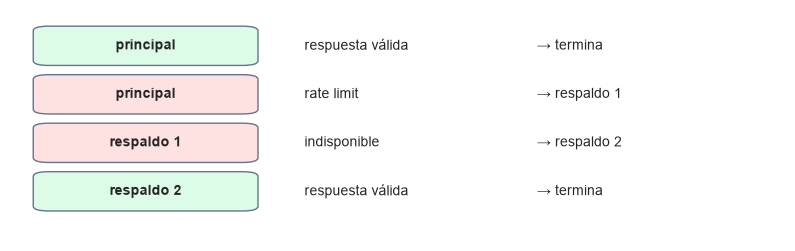

,modelo intentado,resultado técnico,siguiente paso,hubo fallback
0,principal,respuesta válida,termina,False
1,principal,rate limit,respaldo 1,True
2,respaldo 1,indisponible,respaldo 2,True
3,respaldo 2,respuesta válida,termina,True


In [9]:
# Se exige contrato completo y que el candidato atienda la mayoría de casos tras el reintento.
# Un 429 aislado no lo descarta: reduce su disponibilidad y queda registrado.
CONTRATO_MINIMO = ['esquema_valido', 'ruta_correcta', 'abstencion_correcta', 'sin_error']
resumen_elegible = resumen[resumen[CONTRATO_MINIMO].eq(1).all(axis=1) & (resumen['principal_atendio'] >= .75)] if not resumen.empty else pd.DataFrame()
CASCADA_PROPUESTA = resumen_elegible.index[:3].tolist()
print('Elegibles con 100% de contrato:', len(resumen_elegible))
print('Orden seleccionado:', CASCADA_PROPUESTA if len(CASCADA_PROPUESTA) == 3 else 'pendiente: hacen falta tres modelos elegibles')
traza_cascada = pd.DataFrame([['principal', 'respuesta válida', 'termina', False], ['principal', 'rate limit', 'respaldo 1', True], ['respaldo 1', 'indisponible', 'respaldo 2', True], ['respaldo 2', 'respuesta válida', 'termina', True]], columns=['modelo intentado','resultado técnico','siguiente paso','hubo fallback'])
fig, ax=plt.subplots(figsize=(10,3)); ax.axis('off')
for i,row in traza_cascada.iterrows():
    y=.78-i*.21; color='#dcfce7' if row['resultado técnico']=='respuesta válida' else '#fee2e2'
    ax.add_patch(FancyBboxPatch((.05,y),.25,.13,boxstyle='round,pad=.02',facecolor=color,edgecolor='#64748b'))
    ax.text(.175,y+.065,row['modelo intentado'],ha='center',va='center',weight='bold'); ax.text(.38,y+.065,row['resultado técnico'],va='center'); ax.text(.68,y+.065,'→ '+row['siguiente paso'],va='center')
plt.show(); display(traza_cascada)


## 9. Métricas: comparar modelo único y cascada sin engañarse

El principal solo y la cascada se ejecutan de nuevo sobre exactamente los mismos cuatro casos, después de elegir la terna. Se informa de completadas, ruta correcta, latencia, USD, fallbacks y modelo real. Los cuatro gráficos permiten ver si la disponibilidad ganada justifica una caída de calidad, tiempo o coste.


,sistema,pregunta,completada,ruta_correcta,latencia_s,usd,hubo_fallback,modelo_real,ruta_observada,error
0,principal solo,¿Cuál fue el revenue total de NVIDIA (NVDA) en...,True,True,3.226393,None,False,inclusionai/ling-3.0-flash-fin:free,get_xbrl_fact,None
1,principal solo,"Según el 10-K de Microsoft (MSFT) FY2025, ¿qué...",True,True,4.624515,None,False,inclusionai/ling-3.0-flash-fin:free,search_filings,None
2,cascada,¿Cuál fue el revenue total de NVIDIA (NVDA) en...,True,True,2.978974,None,False,inclusionai/ling-3.0-flash-fin:free,get_xbrl_fact,None
3,cascada,"Según el 10-K de Microsoft (MSFT) FY2025, ¿qué...",True,True,5.558198,None,False,inclusionai/ling-3.0-flash-fin:free,search_filings → list_available,None


,sistema,preguntas,completadas_%,ruta_correcta_%,latencia_mediana_s,usd_total,fallbacks
0,cascada,2,100.0,100.0,4.269,NaN,0
1,principal solo,2,100.0,100.0,3.925,NaN,0


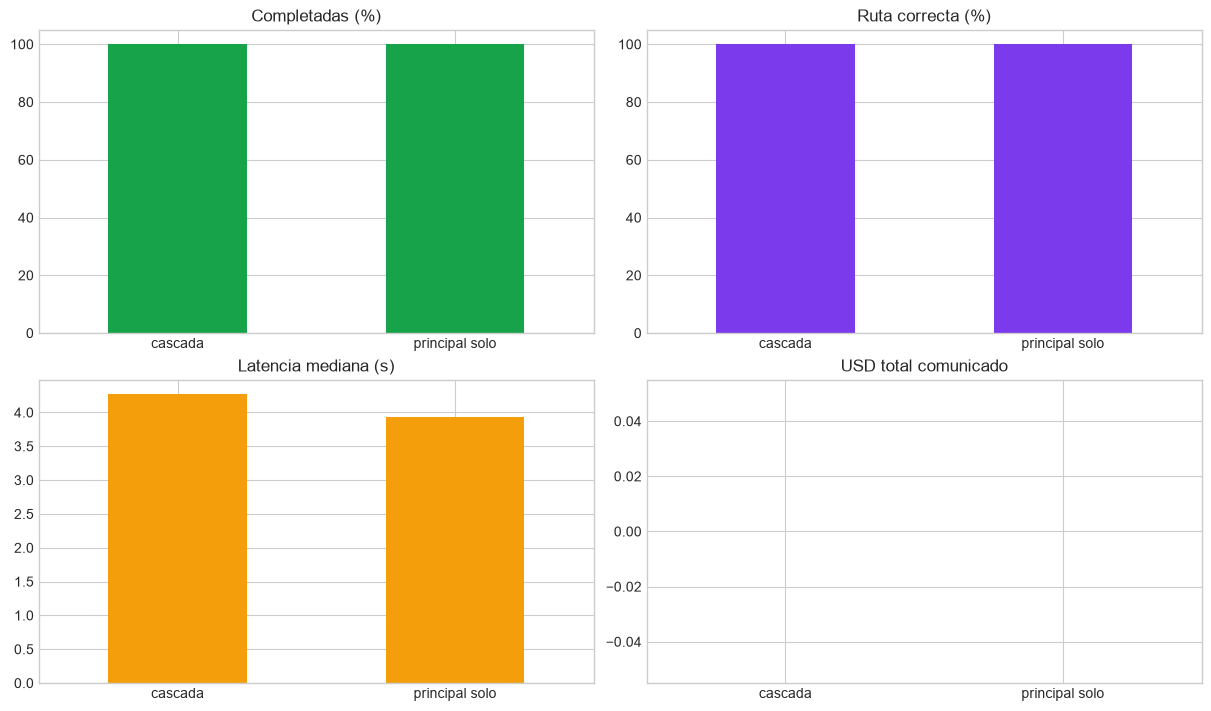

In [10]:
filas_comparacion = []
if EJECUTAR_API and config.cargar_clave() and len(CASCADA_PROPUESTA) == 3:
    experimentos = [('principal solo', 'baseline', CASCADA_PROPUESTA[0], []),
                    ('cascada', 'cascada', CASCADA_PROPUESTA[0], CASCADA_PROPUESTA[1:])]
    for nombre_sistema, sistema, principal, suplentes in experimentos:
        for _, caso in CASOS_BANCO.iterrows():
            resultado = agente.ejecutar(caso['pregunta'], sistema=sistema, modelo=principal, fallbacks=suplentes)
            nombres_ruta = [llamada['name'] for llamada in resultado['tool_calls']]
            filas_comparacion.append({'sistema': nombre_sistema, 'pregunta': caso['pregunta'],
                'completada': resultado['error'] is None,
                'ruta_correcta': caso['ruta esperada'] in nombres_ruta,
                'latencia_s': resultado['latencia_s'], 'usd': resultado['usd_openrouter'],
                'hubo_fallback': resultado['hubo_fallback'], 'modelo_real': resultado['modelo_real'],
                'ruta_observada': ' → '.join(nombres_ruta) or 'sin herramienta', 'error': resultado['error']})
resultados_comparacion = pd.DataFrame(filas_comparacion)
columnas_comparacion = ['sistema','preguntas','completadas_%','ruta_correcta_%','latencia_mediana_s','usd_total','fallbacks']
comparacion = pd.DataFrame(columns=columnas_comparacion)
if not resultados_comparacion.empty:
    comparacion = resultados_comparacion.groupby('sistema').agg(
        preguntas=('pregunta', 'size'), completadas_pct=('completada', lambda x: 100 * x.mean()),
        ruta_correcta_pct=('ruta_correcta', lambda x: 100 * x.mean()),
        latencia_mediana_s=('latencia_s', 'median'), usd_total=('usd', lambda x: x.sum(min_count=1)),
        fallbacks=('hubo_fallback', 'sum')).reset_index().rename(columns={'completadas_pct': 'completadas_%', 'ruta_correcta_pct': 'ruta_correcta_%'})
    display(resultados_comparacion); display(comparacion.round(3))
    fig, ejes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
    metricas = [('completadas_%', 'Completadas (%)', '#16a34a'), ('ruta_correcta_%', 'Ruta correcta (%)', '#7c3aed'),
                ('latencia_mediana_s', 'Latencia mediana (s)', '#f59e0b'), ('usd_total', 'USD total comunicado', '#2563eb')]
    for eje, (columna, titulo, color) in zip(ejes.flat, metricas):
        comparacion.set_index('sistema')[columna].fillna(0).plot.bar(ax=eje, color=color, title=titulo)
        eje.set_xlabel(''); eje.tick_params(axis='x', rotation=0)
    plt.show()
else:
    print('Comparación pendiente: activa API y obtén tres candidatos válidos en el banco.')


## 10. Comprobación local sin red

Estas pruebas verifican el contrato, el fallback de respuesta, hilos independientes y la extracción de trayectoria. No validan calidad financiera ni disponibilidad de proveedores: eso es precisamente lo que medirán el banco y el golden set.

Al terminar en verde, el notebook puede compartirse o revisarse sin clave y sin coste.


In [11]:
import pytest
# Los dobles de los tests verifican el baseline oficial, no el arnés API.
_modo_acotado = os.environ.pop('AGENTE10K_MODO_ACOTADO', None)
estado = pytest.main(['-q', str(RAIZ/'tests'/'test_agente.py'), str(RAIZ/'tests'/'test_contratos.py'), '-p', 'no:cacheprovider'])
if _modo_acotado is not None: os.environ['AGENTE10K_MODO_ACOTADO'] = _modo_acotado
assert estado == 0
print('✓ Contrato y arnés comprobados sin red.')


.

.

.

.

.

...

.

.

                                                         [100%]


============================== warnings summary ===============================
..\..\..\..\..\..\..\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345
  C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; anyio
    self._mark_plugins_for_rewrite(hook, disable_autoload)

..\..\..\..\..\..\..\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345
  C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; langsmith
    self._mark_plugins_for_rewrite(hook, disable_autoload)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
16 passed, 2 warnings in 0.93s


✓ Contrato y arnés comprobados sin red.


## Cierre

El baseline queda como referencia estable. La cascada ya se ejecuta con los tres candidatos mejor puntuados y deja su trazabilidad; deberá evaluarse sobre el golden set antes de declararla mejor.
